# Week 7：最终模型与封存测试集

目标：根据前一节的交叉验证结果确定候选模型，使用完整开发集重新训练，并只在封存测试集上做一次最终评估。

已完成的模型比较显示：Logistic Regression 的交叉验证准确率均值最高，且波动最小。因此本节选它作为最终候选模型。

## 最终工作流

1. 之前：在开发集上交叉验证、比较模型、确定逻辑回归。
2. 现在：用全部开发集训练这个已确定的流程。
3. 最后：只评估一次封存测试集，得到对未来新样本的最终估计。

本节不再根据测试结果回头修改模型；若要开始新的调参周期，需要重新保留独立测试集。

In [1]:
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, classification_report,
    roc_auc_score, RocCurveDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [2]:
dataset = load_breast_cancer(as_frame=True)
X = dataset.data
y = dataset.target

# 与模型比较 Notebook 使用相同划分；X_test 到本单元前都没有参与训练或模型选择。
X_develop, X_test, y_develop, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

In [3]:
final_model = Pipeline([
    # 在完整开发集上学习均值与标准差。
    ('scaler', StandardScaler()),
    # 前序交叉验证已确定的最终候选模型。
    ('model', LogisticRegression(max_iter=1000, random_state=42)),
])

# 此处是真正的最终训练：用全部开发集拟合一次。
final_model.fit(X_develop, y_develop)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [4]:
# 测试集只在这里首次使用，得到最终评估结果。
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

print(f'final test accuracy: {accuracy_score(y_test, y_pred):.3f}')
print(f'final test ROC-AUC:  {roc_auc_score(y_test, y_proba):.3f}')
print('\nclassification report:')
print(classification_report(y_test, y_pred, target_names=dataset.target_names))

final test accuracy: 0.982
final test ROC-AUC:  0.995

classification report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



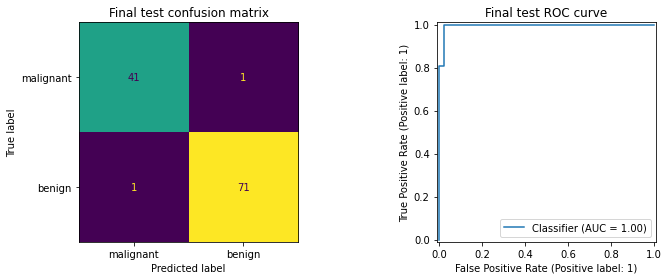

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# 左图：固定阈值 0.5 时，各类预测的数量。
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=dataset.target_names, ax=axes[0], colorbar=False
)
axes[0].set_title('Final test confusion matrix')

# 右图：不同阈值下的排序能力；曲线越靠近左上角越好。
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].set_title('Final test ROC curve')
plt.tight_layout()
plt.show()

## 交付结论应该怎么写

不要只写一个准确率。至少写清：模型是什么、训练/验证如何完成、最终测试集上的 Accuracy 与 AUC、该任务中漏报和误报各意味着什么，以及当前数据集的局限性。

思考题：若业务把“把恶性肿瘤误判为良性”视为严重错误，应该主要关注报告中的哪项指标？为什么？